# Paper-like Toxicity Summary (No Delta)

This notebook summarizes the cleaned calibrated run and only reports toxicity levels (not toxicity deltas).

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

cwd = Path.cwd().resolve()
if (cwd / 'AppliedControler' / 'results_reports').exists():
    base = cwd / 'AppliedControler' / 'results_reports'
elif cwd.name == 'results_reports' and (cwd / 'paper_style_table_paper_like_calibrated.csv').exists():
    base = cwd
else:
    # Fallback for notebook execution from repository root inference.
    base = Path('/teamspace/studios/this_studio/LinearLLMDynamic/AppliedControler/results_reports').resolve()

print(f'Using reports directory: {base}')

Using reports directory: /teamspace/studios/this_studio/LinearLLMDynamic/AppliedControler/results_reports


## Main Toxicity Table

In [6]:
table_path = base / 'paper_style_table_paper_like_calibrated.csv'
df = pd.read_csv(table_path)
view = df[['label', 'subset', 'method', 'toxicity_percent', 'status']].copy()
view = view.sort_values(['label', 'subset', 'method'])
view

,label,subset,method,toxicity_percent,status
1,DistilGPT-2,rtp_random,A-LQR,0.134304,ok
3,DistilGPT-2,rtp_random,H-infinity,0.018961,ok
0,DistilGPT-2,rtp_random,Original,4.453905,ok
2,DistilGPT-2,rtp_random,S-PID,0.040725,ok


In [7]:
orig = df[df['method'] == 'Original'][['label', 'subset', 'toxicity_percent']].copy()
orig = orig.rename(columns={'toxicity_percent': 'original_toxicity_percent'})
orig

,label,subset,original_toxicity_percent
0,DistilGPT-2,rtp_random,4.453905


## Clean Figures (No Delta Charts)

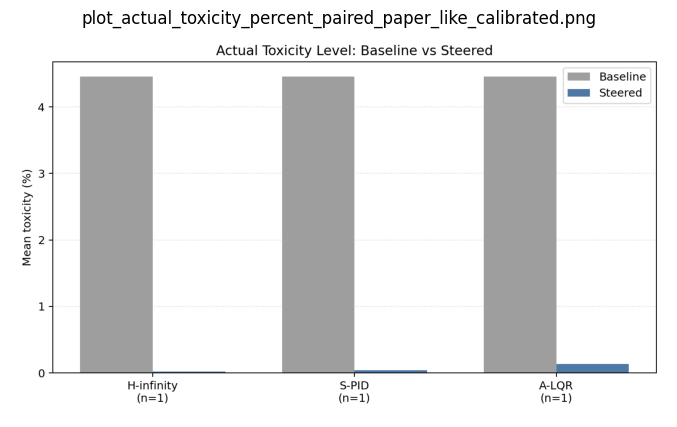

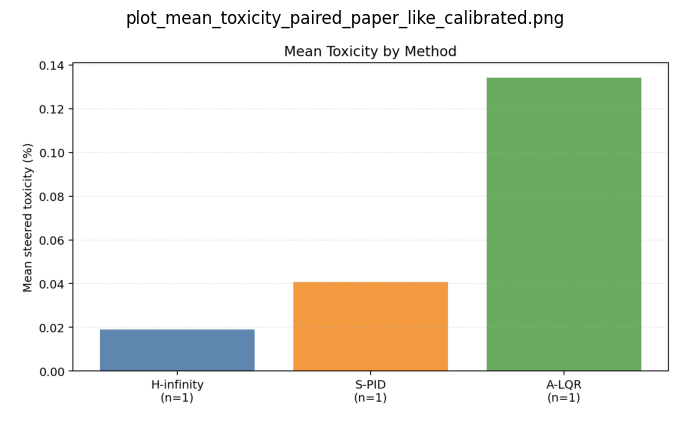

In [8]:
fig_paths = [
    base / 'plot_actual_toxicity_percent_paired_paper_like_calibrated.png',
    base / 'plot_mean_toxicity_paired_paper_like_calibrated.png',
]

for path in fig_paths:
    img = Image.open(path)
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.title(path.name)
    plt.axis('off')
    plt.show()

## Larger Model Check (Qwen 14B Baseline Only)

In [9]:
qwen_files = sorted(base.parent.glob('baseline_calibration_qwen14b*.csv'))
rows = []
for file in qwen_files:
    tmp = pd.read_csv(file)
    tmp['file'] = file.name
    rows.append(tmp)

if rows:
    qwen_df = pd.concat(rows, ignore_index=True)
    qwen_df = qwen_df[['file', 'model_name', 'prompt_toxicity_min', 'prompt_toxicity_max', 'eval_prompts', 'baseline_toxicity_percent']]
    qwen_df = qwen_df.sort_values('file')
    qwen_df
else:
    print('No Qwen14B baseline files found.')